# Crime patterns and bivariate spatial association — CDMX

**Author: Valeria Hernández · Phase 3 · TEAM_PLAN §4.5**

This notebook reads the warehouse views through the shared analysis helpers. It describes reported FGJ investigation files with an offence date in 2024, then tests business density at an AGEB against crime rates in neighbouring AGEBs. Every result is descriptive; spatial association does not establish causation.

Prerequisite: a populated PostgreSQL/PostGIS warehouse built with `python -m src.pipeline all`. Database access uses the existing project environment configuration; no credentials or machine-specific paths are stored here.

**Pinned source coverage:** the published CSV contains files opened from 2024-01-01 through 2024-07-31, confirmed during source profiling. Its SHA-256 is `2ac3f17189a61ab7b2eb95fb21470e46adaba6f92526c7b92d23190ed2431f84`. This is a January-July snapshot, not a complete year. August-December are unavailable; their absence does not mean zero crime. Coverage must be re-profiled if the source version changes.

In [1]:
from pathlib import Path
import sys
import json
import platform
from importlib.metadata import version
from datetime import datetime, timezone

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display
from src.config import CRIME_YEAR, OUTPUT_FIGURES, SOURCES
from src.analysis.data import load_kpis, load_view
from src.analysis.crime_patterns import (
    CRIME_COVERAGE, CRIME_COVERAGE_SHA256, censoring_sensitivity,
    export_temporal_tables, save_temporal_figures, temporal_tables,
)
from src.analysis.crime_bivariate import bivariate_quadrants, bivariate_results, save_bivariate_figure

COVERAGE_START, COVERAGE_END = CRIME_COVERAGE
SENSITIVITY_END = "2024-06-30"  # last complete month before the right-censored July
SEED = 42
PERMUTATIONS = 999
ALPHA = 0.05
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
software = {name: version(name) for name in ["pandas", "numpy", "geopandas", "esda", "libpysal"]}
software["python"] = platform.python_version()
display(pd.Series(software, name="Version").to_frame())

,Version
pandas,3.0.6
numpy,2.5.3
geopandas,1.2.0
esda,2.10.0
libpysal,4.15.0
python,3.12.10


## 1. Warehouse coverage and temporal patterns

**Scope decision:** temporal counts include all urban AGEBs, including outlying urban localities and low-population AGEBs, so the summaries reconcile with the full warehouse crime total. They use counts and calendar-day averages, with no population denominator. The bivariate analysis below preserves the default city-core and low-population filters.

The temporal view is already grouped by AGEB, type, month, ISO weekday and time band. We sum its `incidents` weights rather than counting view rows. Empty bins inside the source window are zero; months outside it remain unavailable (NULL); unknown hours remain separate. Calendar adjustments account for 29/30/31-day months and the number of occurrences of each weekday within the profiled 213-day January-July window. These averages are not annualised.

The combined temporal figure compares month, weekday and time band by analytical crime category. Each category table reconciles to the retained incident total; unknown hours remain explicit.

In [2]:
all_kpis = load_kpis(city_core_only=False, exclude_low_population=False)
assert len(all_kpis) == 2431 and all_kpis["cvegeo"].is_unique
assert all_kpis["pop_total"].notna().all(), "Load the census before Phase 3"
assert all_kpis.crs.to_epsg() == 6372
sources = load_view("dim_source")
warehouse_sha256 = sources.loc[sources["source_code"].eq("crime_fgj_2024"), "sha256"].item()
assert warehouse_sha256 == CRIME_COVERAGE_SHA256, "Warehouse FGJ file differs from the profiled one: re-profile its coverage"
warehouse_total = int(all_kpis["crime_total"].sum())
display(pd.Series({
    "Urban AGEBs": len(all_kpis),
    "City-core AGEBs": int(all_kpis["is_city_core"].sum()),
    "AGEBs with population < 100": int(all_kpis["low_population"].sum()),
    "Residents (Census 2020)": int(all_kpis["pop_total"].sum()),
    "Businesses (DENUE snapshot)": int(all_kpis["businesses_total"].sum()),
    "Retained investigation files": warehouse_total,
}, name="Warehouse coverage").to_frame())

,Warehouse coverage
Urban AGEBs,2431
City-core AGEBs,2348
AGEBs with population < 100,55
Residents (Census 2020),9138524
Businesses (DENUE snapshot),461231
Retained investigation files,112285


Temporal view: 107,750 grouped rows representing 112,285 files.
monthly


,incidents,month_name,calendar_days,incidents_per_day,right_censored,share_pct
month,,,,,,
1,15840,Jan,31,510.968,False,14.107
2,16220,Feb,29,559.31,False,14.445
3,17181,Mar,31,554.226,False,15.301
4,16957,Apr,30,565.233,False,15.102
5,17449,May,31,562.871,False,15.54
6,15675,Jun,30,522.5,False,13.96
7,12963,Jul,31,418.161,True,11.545
8,<NA>,Aug,0,<NA>,False,<NA>
9,<NA>,Sep,0,<NA>,False,<NA>


weekday


,incidents,day_name,calendar_days,incidents_per_day,share_pct
day_of_week,,,,,
1,16776,Monday,31,541.161,14.941
2,16726,Tuesday,31,539.548,14.896
3,16497,Wednesday,31,532.161,14.692
4,16553,Thursday,30,551.767,14.742
5,17019,Friday,30,567.300,15.157
6,14505,Saturday,30,483.500,12.918
7,14209,Sunday,30,473.633,12.654


time_band


,incidents,share_pct
time_band,,
Night (00-05),14875,13.248
Morning (06-11),32186,28.665
Afternoon (12-17),37863,33.720
Evening (18-23),27191,24.216
Unknown,170,0.151


crime_type


,crime_type,crime_category,incidents,share_pct
0,Family Violence,Violent,20163,17.957
1,Threats,Violent,11290,10.055
2,Fraud,Property,8861,7.892
3,Theft of Auto Parts and Accessories,Property,5485,4.885
4,Theft of Personal Property,Property,4374,3.895
5,Identity Theft,Property,3881,3.456
6,Theft from Vehicle Interior,Property,3384,3.014
7,Robbery on Public Road with Violence,Property,3265,2.908
8,Negligent Traffic Damage to an Automobile,Other,2108,1.877
9,Sexual Abuse,Sexual,1856,1.653


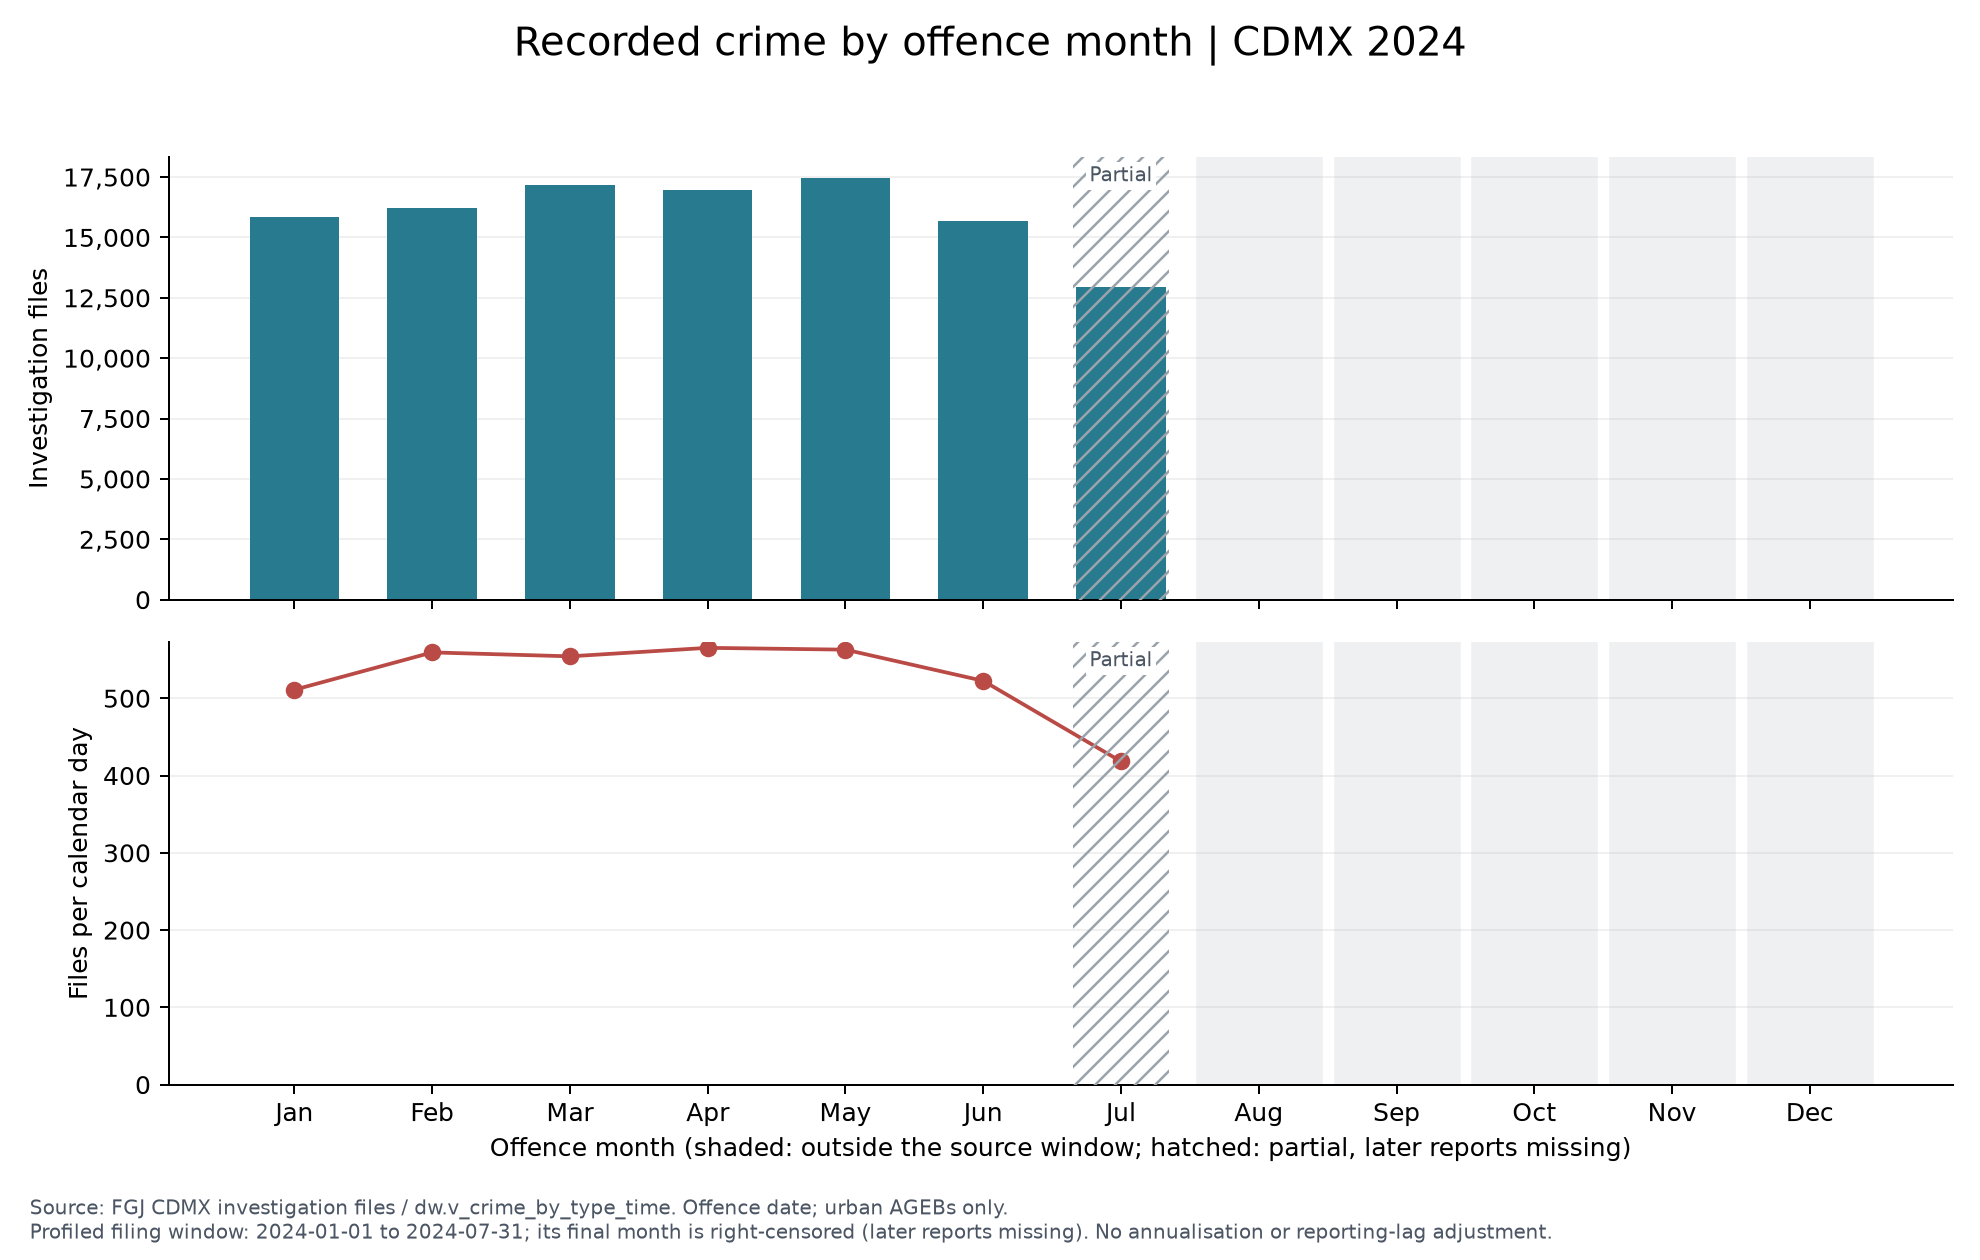

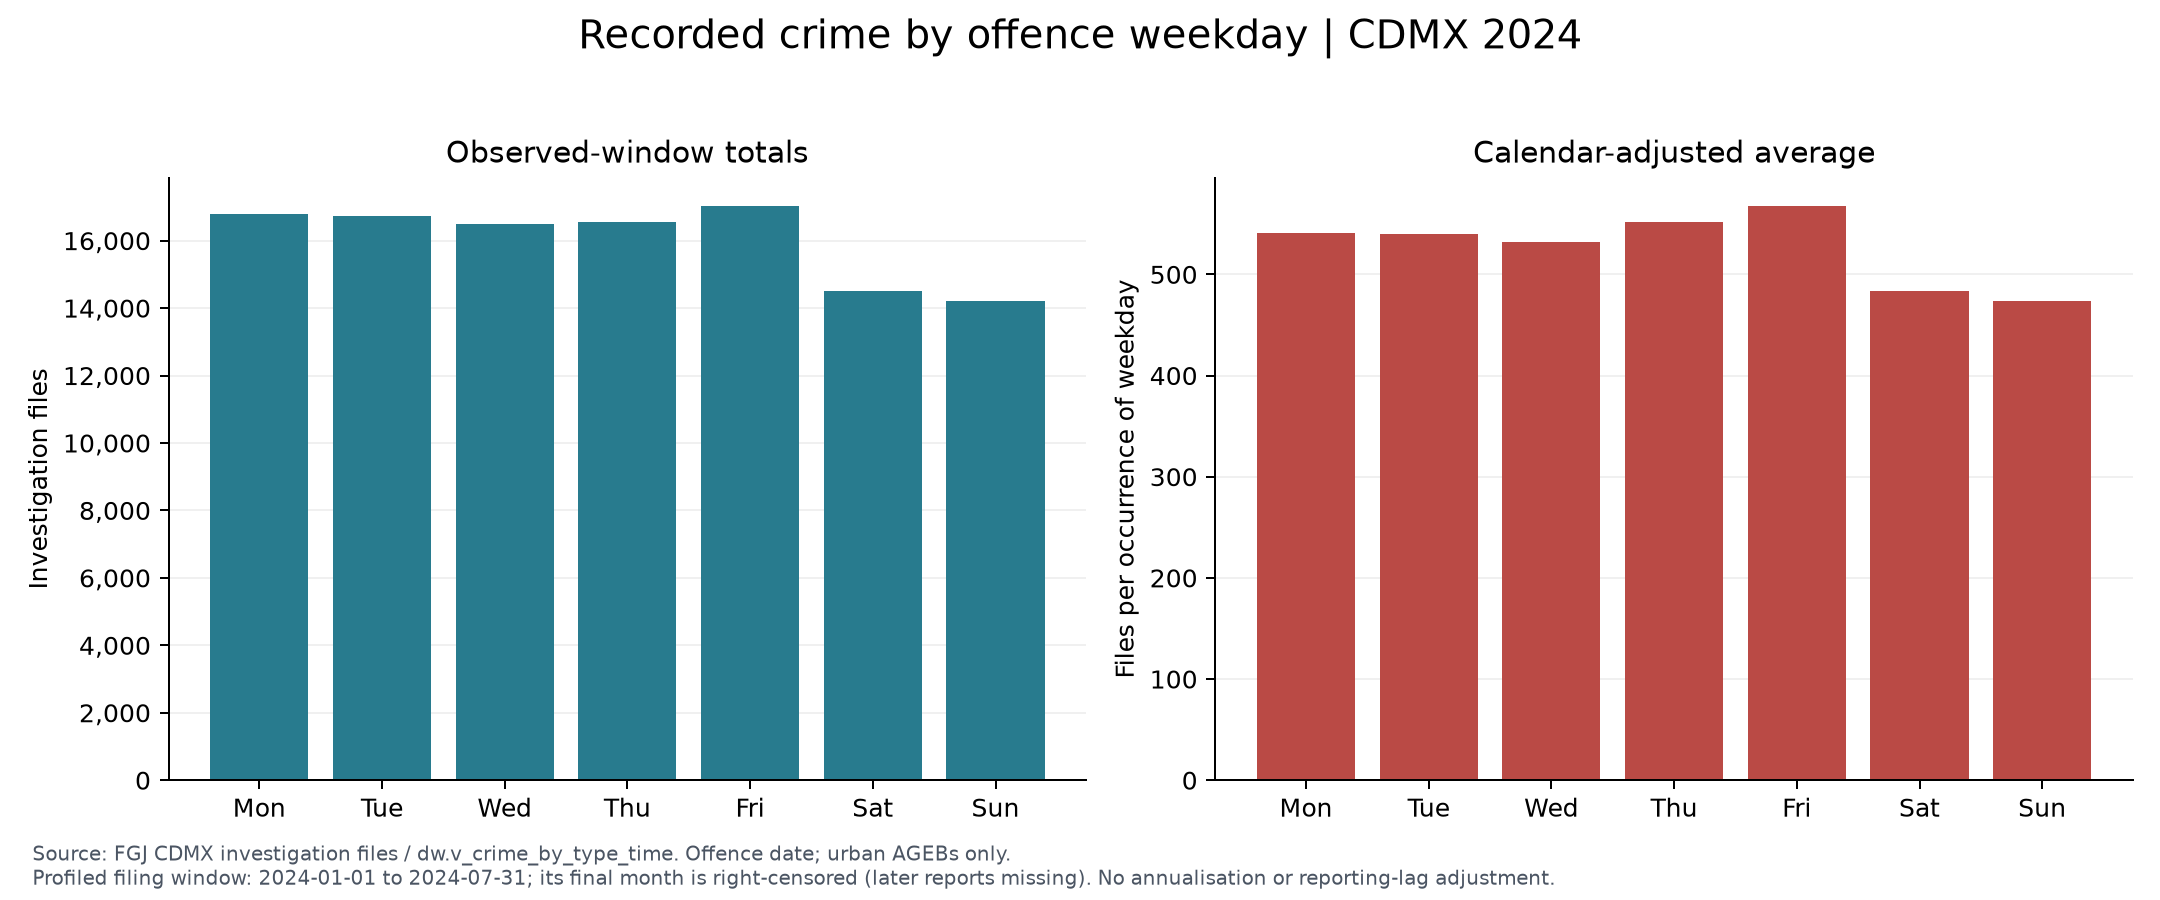

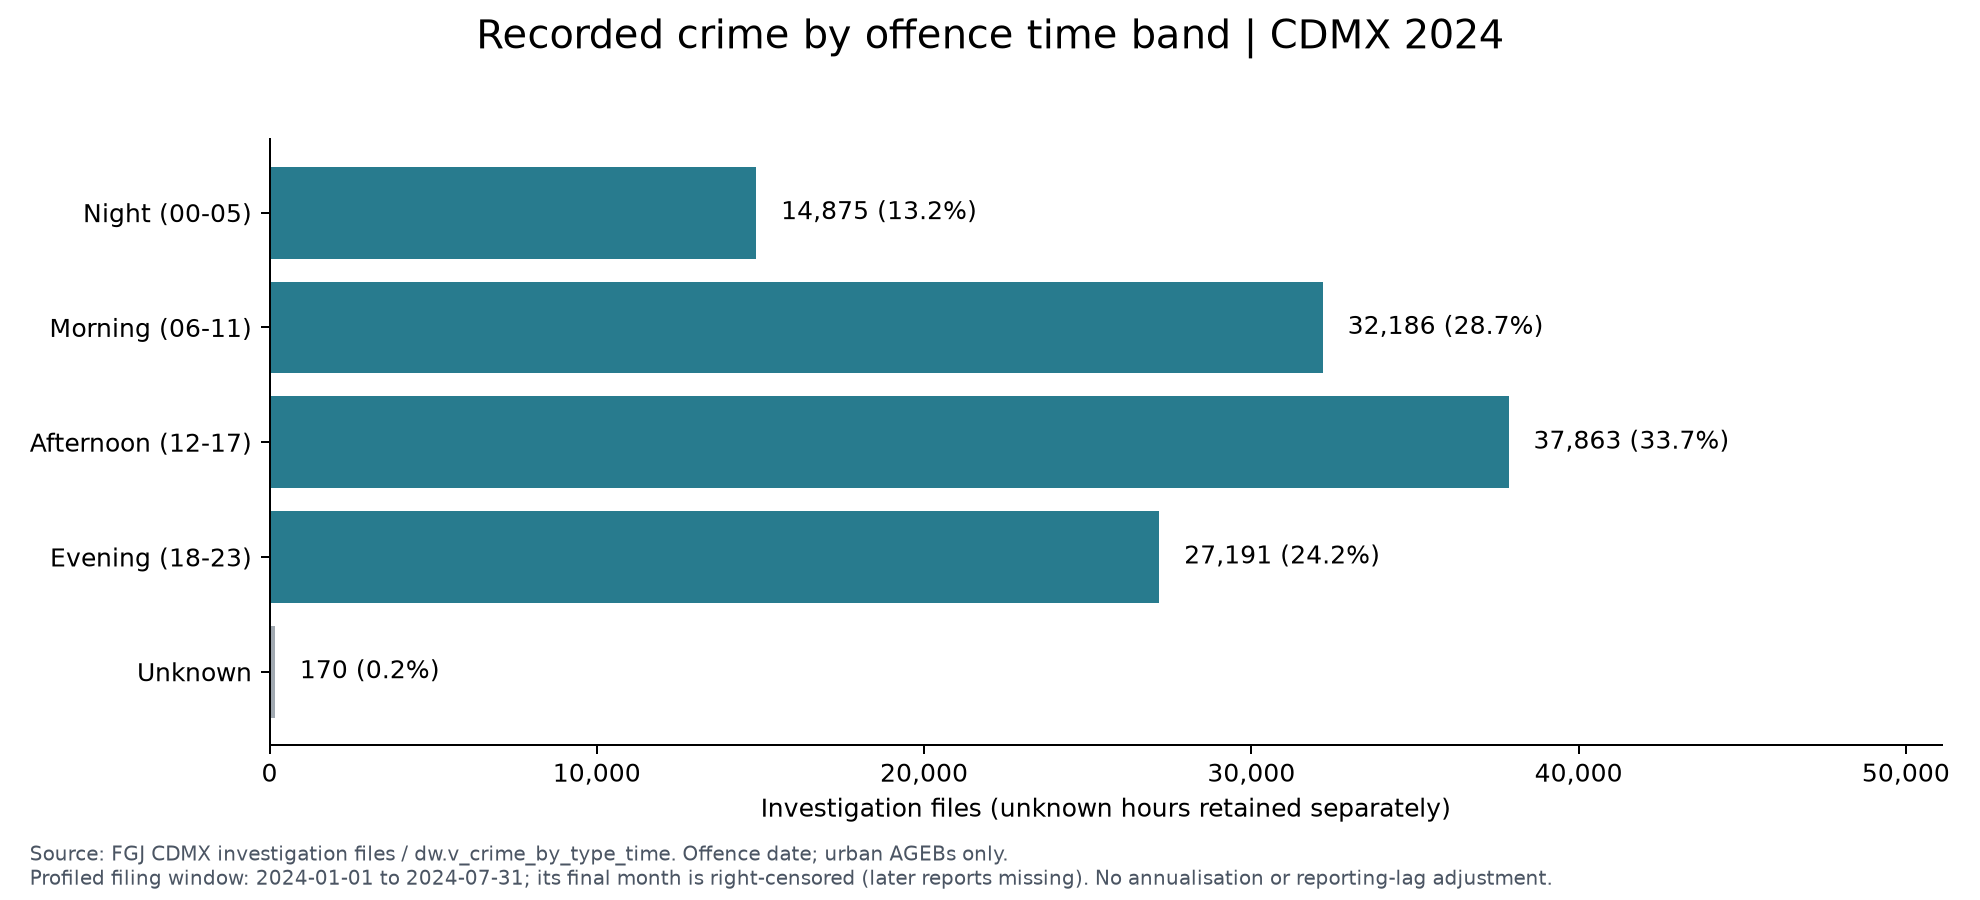

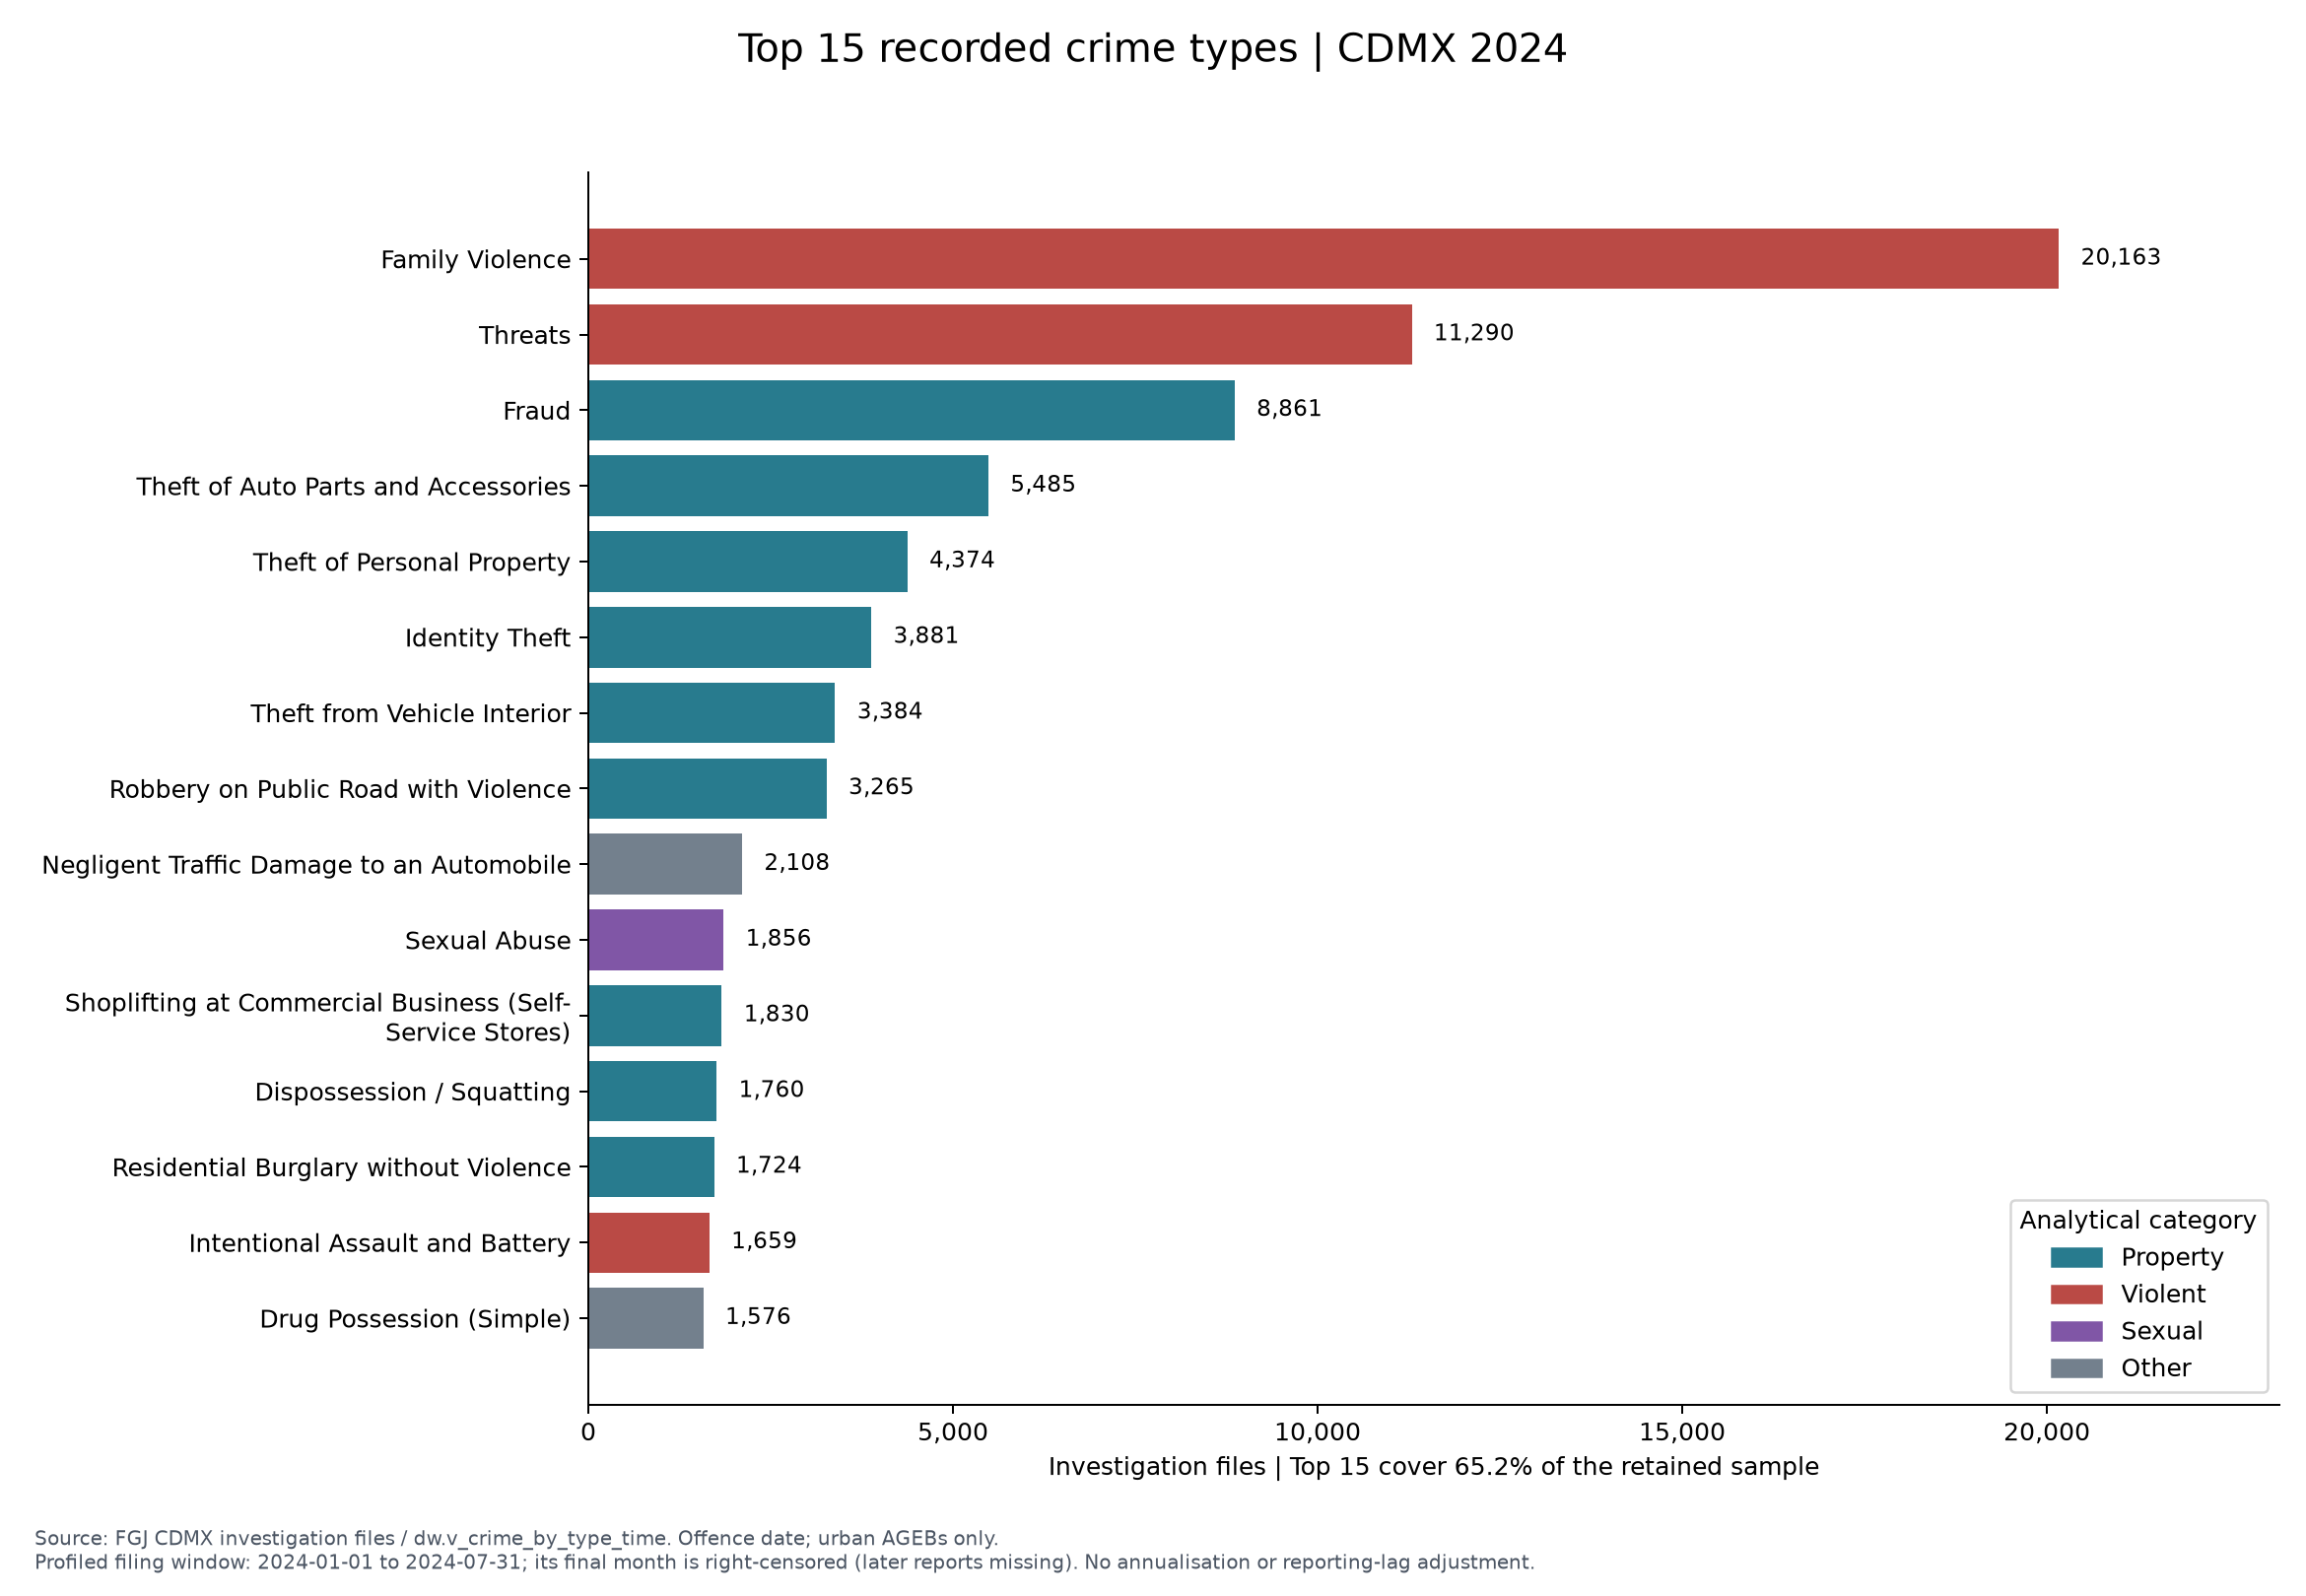

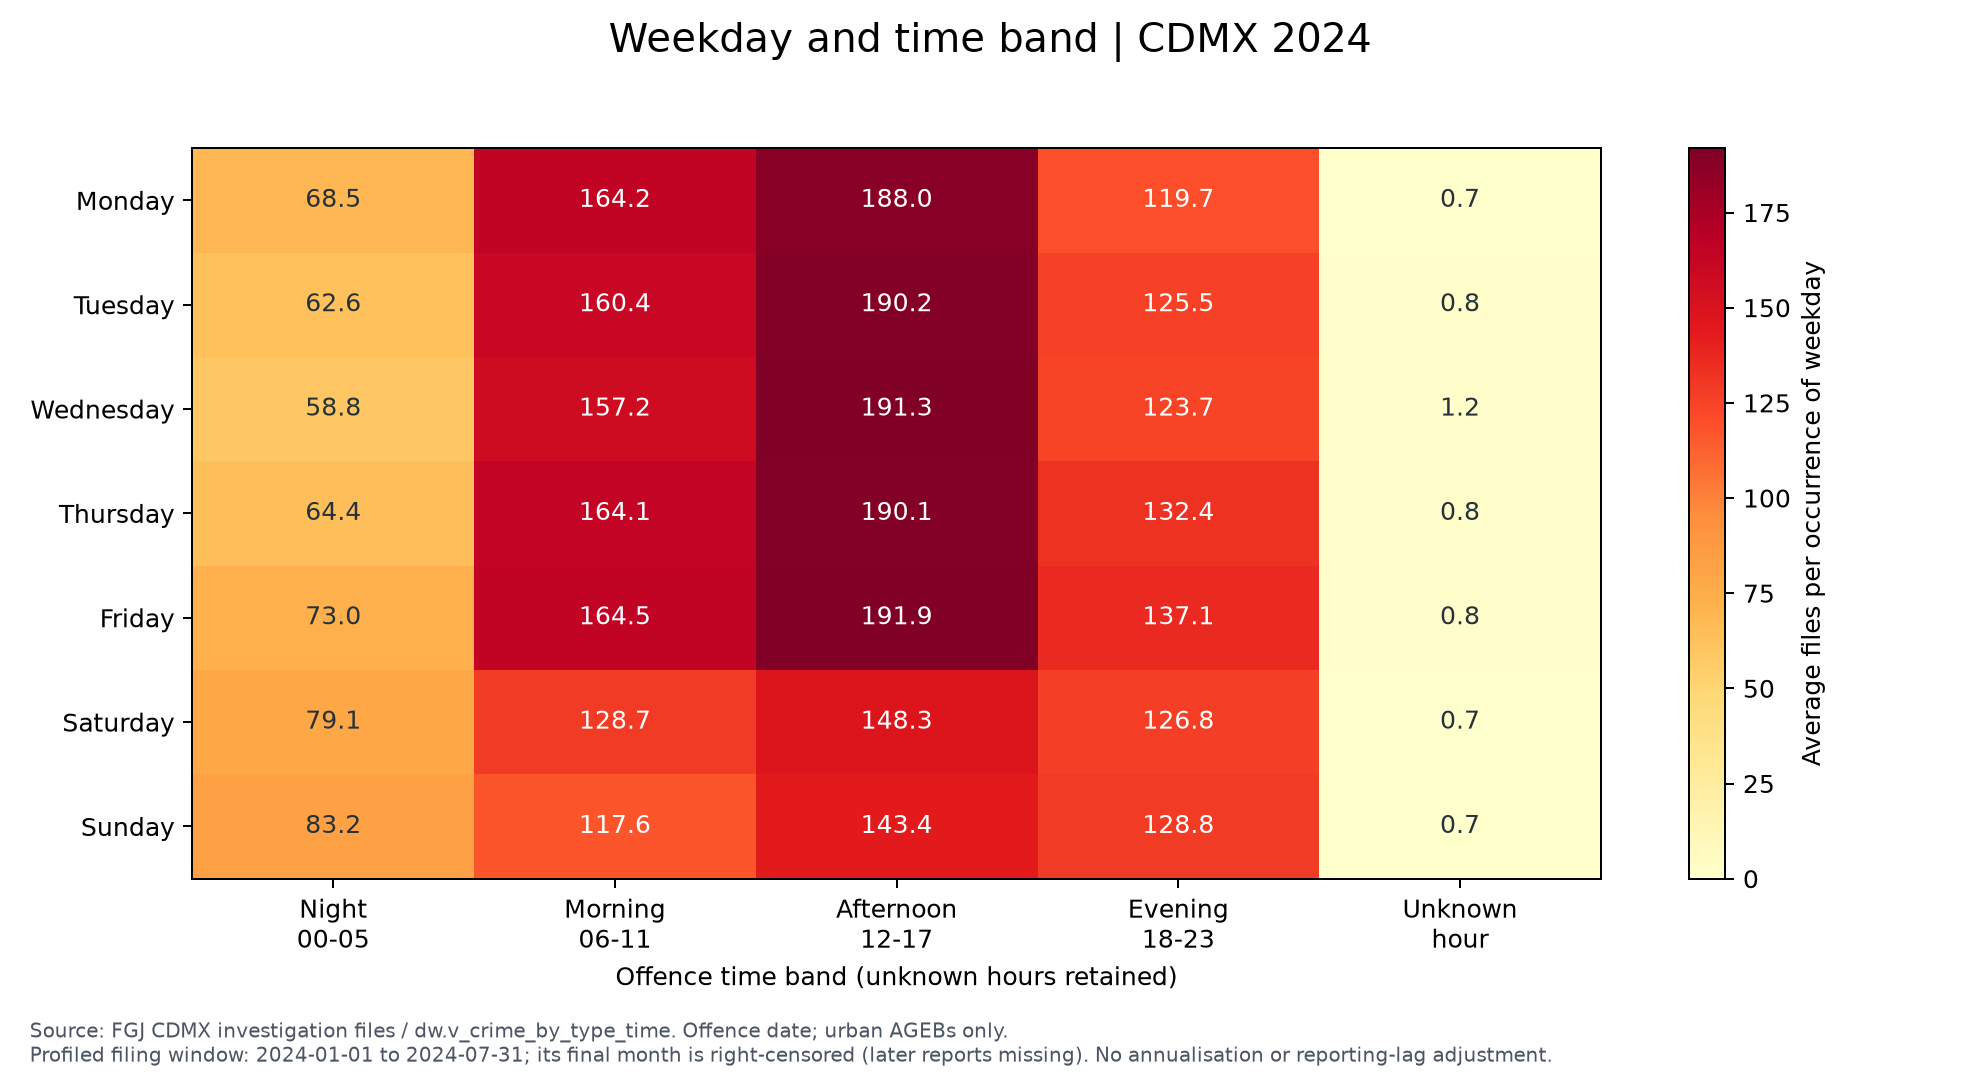

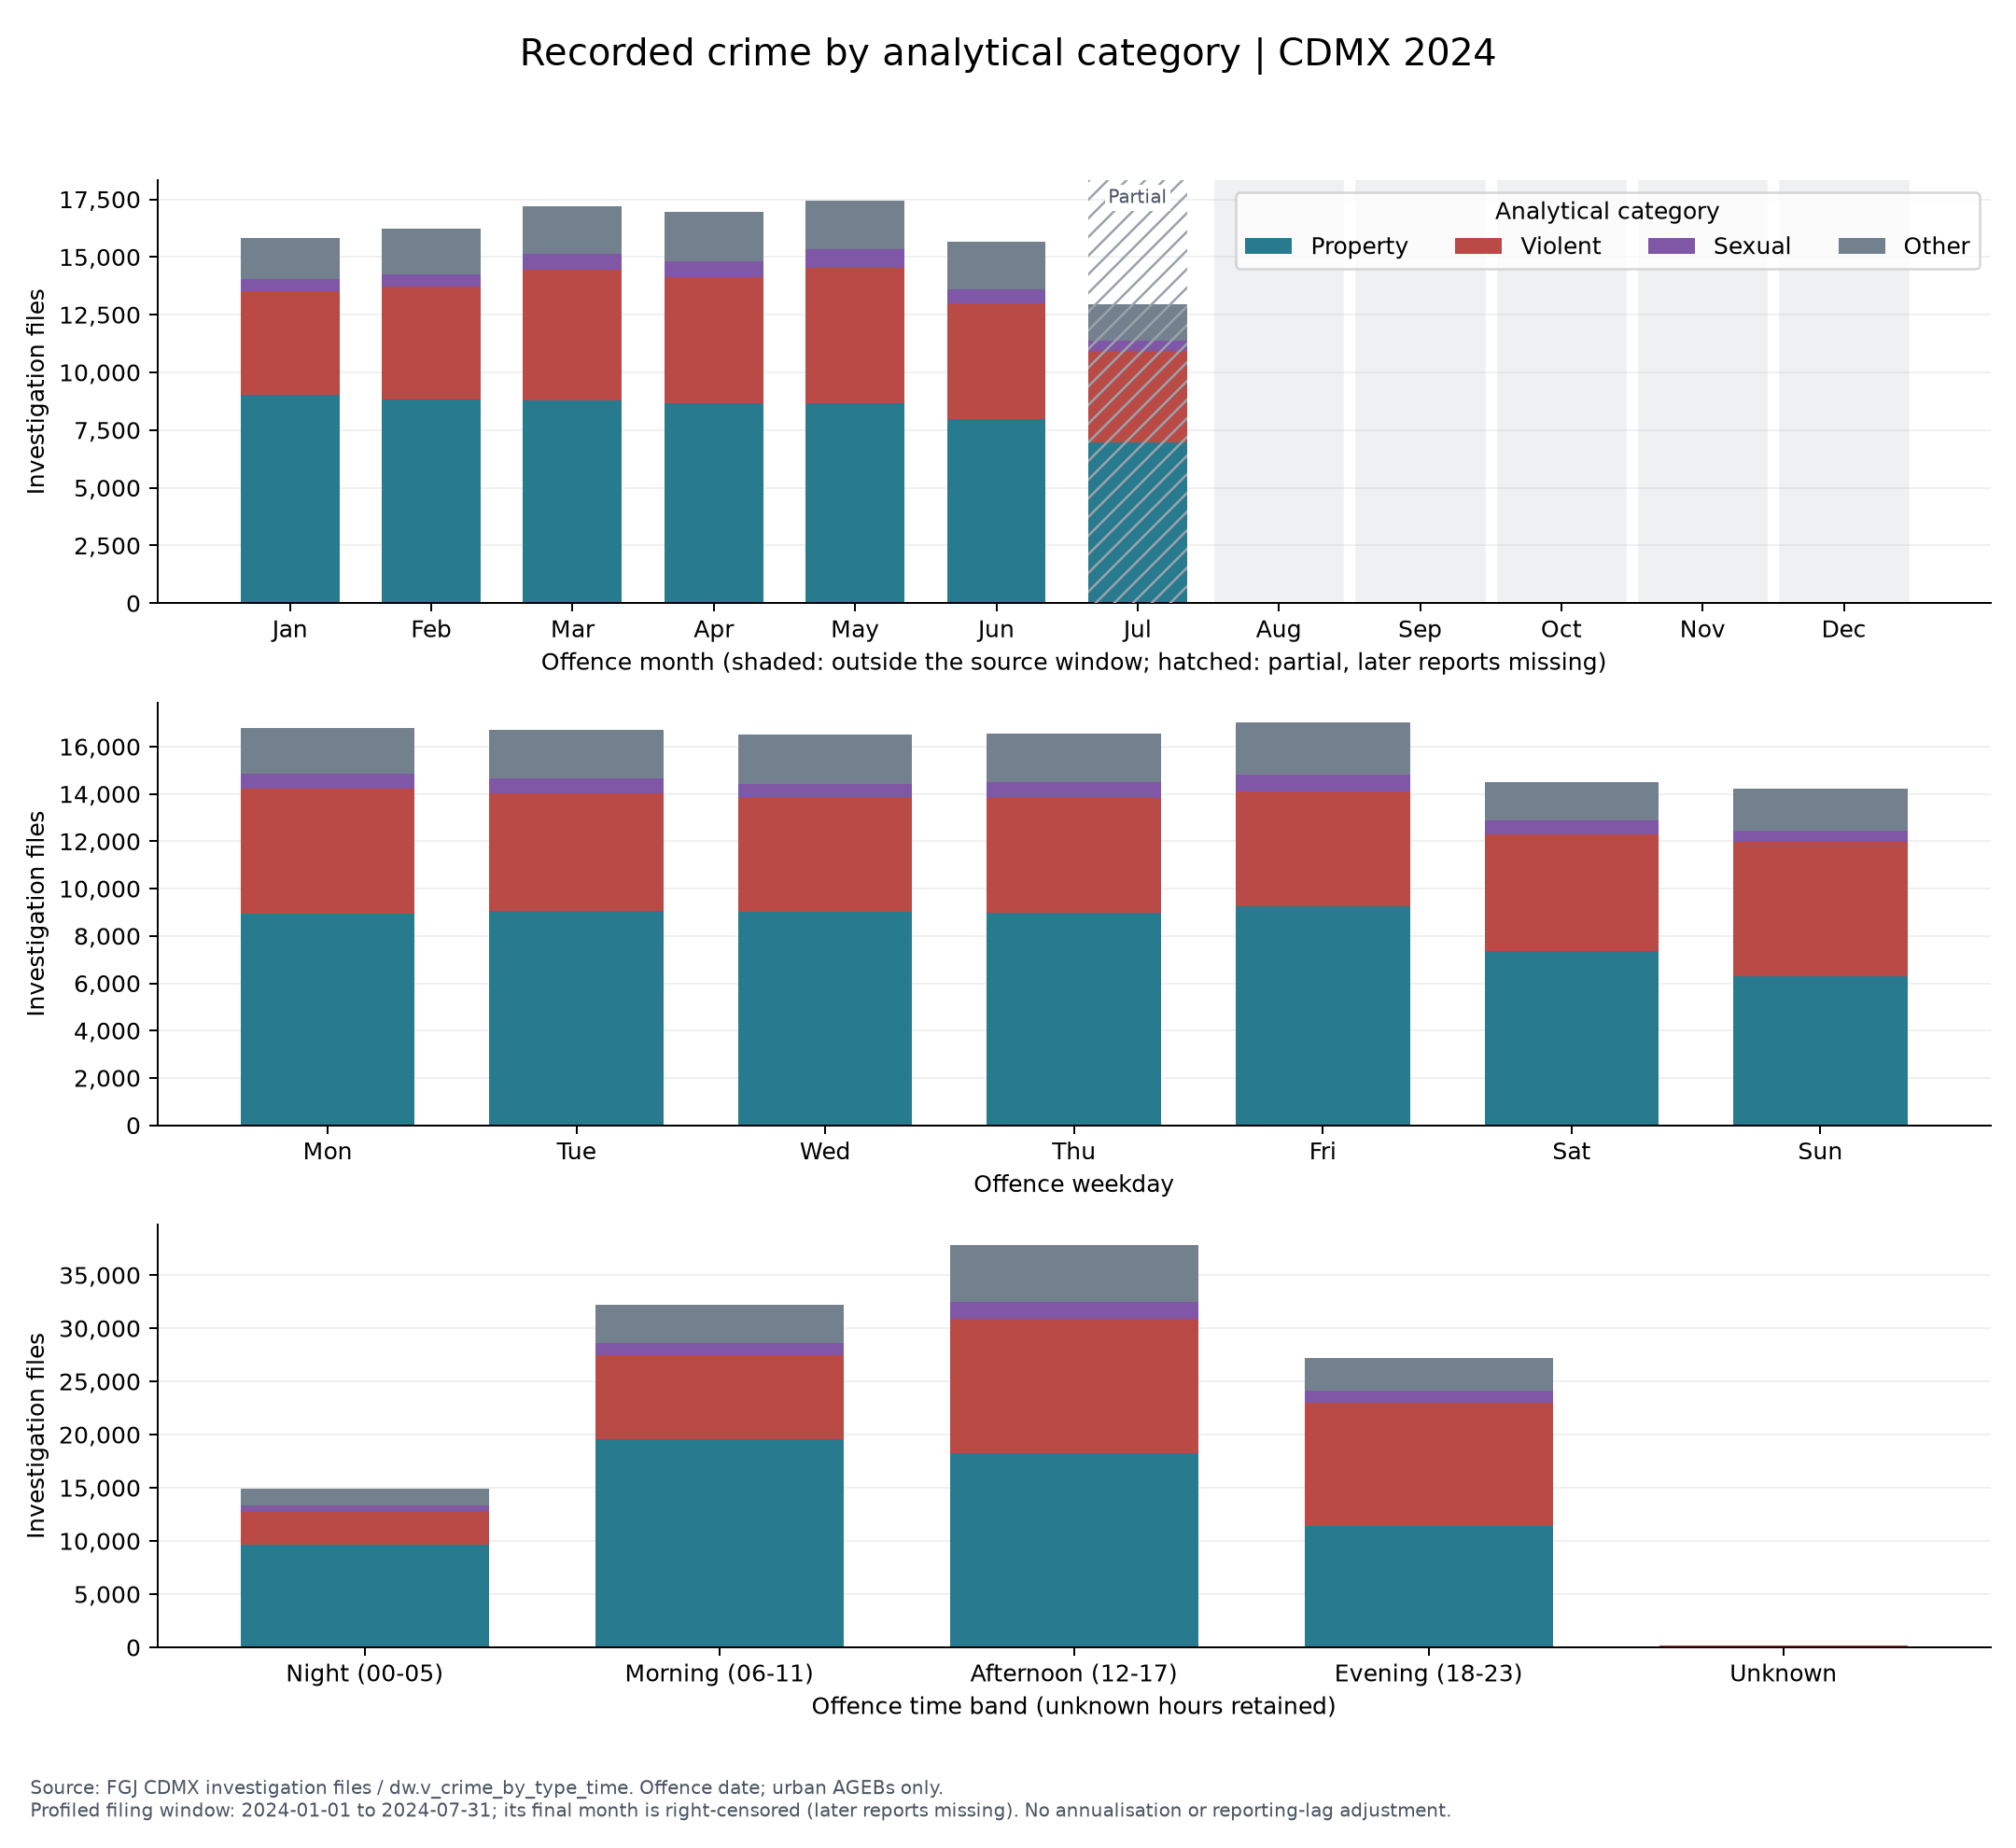

In [3]:
temporal_view = load_view("v_crime_by_type_time")
tables = temporal_tables(temporal_view, year=CRIME_YEAR,
                         coverage_start=COVERAGE_START, coverage_end=COVERAGE_END)
assert int(tables["monthly"]["incidents"].sum()) == warehouse_total
print(f"Temporal view: {len(temporal_view):,} grouped rows representing {warehouse_total:,} files.")
for name in ["monthly", "weekday", "time_band", "crime_type"]:
    print(name)
    display(tables[name].head(15).round(3))
table_paths = export_temporal_tables(tables, OUTPUT_FIGURES)
figure_paths = save_temporal_figures(tables, OUTPUT_FIGURES, year=CRIME_YEAR)
for path in figure_paths.values():
    display(Image(filename=str(path)))

In [4]:
monthly = tables["monthly"]
weekday = tables["weekday"]
peak_weekday = weekday["incidents_per_day"].idxmax()
unknown = tables["time_band"].loc["Unknown"]
top_months = monthly.dropna(subset=["incidents_per_day"]).nlargest(2, "incidents_per_day")
first, second = top_months.iloc[0], top_months.iloc[1]
print(f"Highest calendar-adjusted months: {first['month_name']} ({first['incidents_per_day']:.2f} files per day) "
      f"and {second['month_name']} ({second['incidents_per_day']:.2f}), "
      f"{100 * (first['incidents_per_day'] / second['incidents_per_day'] - 1):.1f}% apart.")
print(f"Highest calendar-adjusted weekday: {weekday.loc[peak_weekday, 'day_name']} "
      f"({weekday.loc[peak_weekday, 'incidents_per_day']:.2f} files per occurrence).")
print(f"Unknown offence hours: {int(unknown['incidents']):,} ({unknown['share_pct']:.3f}%).")
print(f"Top 15 harmonised types account for {tables['crime_type'].head(15)['share_pct'].sum():.2f}% of files.")

Highest calendar-adjusted months: Apr (565.23 files per day) and May (562.87), 0.4% apart.
Highest calendar-adjusted weekday: Friday (567.30 files per occurrence).
Unknown offence hours: 170 (0.151%).
Top 15 harmonised types account for 65.21% of files.


### Right-censoring check

The filing window ends on 31 July, so offences from late July whose files were opened in August are missing. July is therefore hatched as **partial** in the monthly charts. The weekday averages above use every day of the window, including that censored tail. The table below recomputes them on the complete months only (January-June). It is a sensitivity check, not a reporting-lag correction.

In [5]:
sensitivity = censoring_sensitivity(temporal_view, SENSITIVITY_END, year=CRIME_YEAR,
                                    coverage_start=COVERAGE_START, coverage_end=COVERAGE_END)
sensitivity_path = OUTPUT_FIGURES / "crime_weekday_sensitivity.csv"
sensitivity.to_csv(sensitivity_path)
display(sensitivity.round(2))
complete = monthly["calendar_days"].gt(0) & ~monthly["right_censored"]
complete_rate = monthly.loc[complete, "incidents"].sum() / monthly.loc[complete, "calendar_days"].sum()
censored = monthly.loc[monthly["right_censored"]].iloc[0]
print(f"{censored['month_name']} (partial): {censored['incidents_per_day']:.2f} files per day vs "
      f"{complete_rate:.2f} in the complete months "
      f"({100 * (censored['incidents_per_day'] / complete_rate - 1):.1f}%).")
leaders = {column: ", ".join(sensitivity.loc[sensitivity[column].eq(1), "day_name"])
           for column in ["full_window_rank", "complete_months_rank"]}
print(f"Excluding {censored['month_name']} raises weekday averages by "
      f"{sensitivity['change_pct'].min():.1f}% to {sensitivity['change_pct'].max():.1f}%; "
      f"highest weekday: {leaders['full_window_rank']} (full window), "
      f"{leaders['complete_months_rank']} (complete months).")


,day_name,full_window_per_day,complete_months_per_day,change_pct,full_window_rank,complete_months_rank
day_of_week,,,,,,
1,Monday,541.16,560.69,3.61,3,4
2,Tuesday,539.55,562.23,4.20,4,3
3,Wednesday,532.16,559.77,5.19,5,5
4,Thursday,551.77,567.35,2.82,2,2
5,Friday,567.30,585.62,3.23,1,1
6,Saturday,483.50,496.08,2.60,6,6
7,Sunday,473.63,488.35,3.11,7,7


Jul (partial): 418.16 files per day vs 545.73 in the complete months (-23.4%).
Excluding Jul raises weekday averages by 2.6% to 5.2%; highest weekday: Friday (full window), Friday (complete months).


These patterns describe the retained investigation files rather than all crimes, victims or calls to emergency services. The input contains files opened from January through July 2024; filtering offence dates to 2024 cannot recover offences whose files were opened after July. July is especially exposed to right censoring: its per-day average is 23.4% below the complete months, which reflects missing later reports rather than evidence that crime declined. Excluding July raises every weekday average by 2.6-5.2% but leaves Friday as the highest weekday. April and May have the highest calendar-adjusted averages (565.23 and 562.87 files per day, 0.4% apart); this ranking is not robust to reporting lag, and seven months do not establish seasonality. Calendar-day averages do not correct reporting lag, missing coordinates or unequal reporting propensity. The labels and macro-categories are analytical translations; negligent offences are included in `Other`.

## 2. Bivariate Moran's I: business density and neighbouring crime rate

The primary pair is **business density (establishments/km²) at AGEB i → spatial lag of crime rate (January-July snapshot files per 1,000 Census 2020 residents) in neighbours of i**. Direction matters: reversing the variables is a different statistic.

With sample-standardised variables, `I = z_business.T @ W @ z_crime / (n - 1)`. Positive I indicates that above-average business density tends to occur near above-average recorded crime rates (and low near low). It is neither a same-AGEB Pearson correlation nor an estimate of a causal effect.

We use [PySAL esda.Moran_BV](https://pysal.org/esda/stable/generated/esda.Moran_BV.html) with **999 permutations**, seed **42** and α **0.05**. We report the permutation z-score `z_sim` and the library's smaller-tail permutation pseudo p-value `p_sim`; it is not doubled into a two-sided p-value. The minimum attainable value is 0.001. The randomisation fixes x and permutes y across the selected AGEBs; it does not preserve y's spatial autocorrelation or condition on same-AGEB correlation.

In [6]:
kpis = load_kpis()  # city_core_only=True, exclude_low_population=True
pair = ["business_density_km2", "crime_rate_per_1k"]
finite = np.isfinite(kpis[pair].to_numpy(dtype=float)).all(axis=1)
sample = kpis.loc[finite].copy().set_index("cvegeo")
assert sample["is_city_core"].all() and not sample["low_population"].any()
print(f"Default filtered sample: {len(kpis):,} AGEBs; additional incomplete/non-finite pairs: {int((~finite).sum())}.")
print(f"Spatial sample: {len(sample):,}; excluded low-population city-core AGEBs: "
      f"{int((all_kpis['is_city_core'] & all_kpis['low_population']).sum())}.")
display(sample[pair].describe(percentiles=[0.5, 0.9, 0.99]).T.round(3))

Default filtered sample: 2,297 AGEBs; additional incomplete/non-finite pairs: 0.
Spatial sample: 2,297; excluded low-population city-core AGEBs: 51.


,count,mean,std,min,50%,90%,99%,max
business_density_km2,2297.0,783.892,967.589,0.0,616.991,1436.602,4427.350,22207.143
crime_rate_per_1k,2297.0,18.364,55.454,0.0,10.069,26.506,184.712,1436.047


### Neighbourhood and sensitivity choices

Nora's `build_weights` is reused without reimplementing its spatial logic. The primary rule is **Queen contiguity**, row-standardised; islands in the selected sample are attached to their nearest neighbour. **KNN with k=6**, also row-standardised, is the sensitivity check on exactly the same ordered AGEBs. We build weights after filtering; the sample and graph need not have the same connectivity as the full 2,348-unit city core. The result table records components, remaining islands and mean neighbour count.

The raw indicators are the primary specification. A separate **log1p sensitivity** reduces the influence of the extreme right tail without deleting observations or changing the sample. It tests association between transformed indicators and must be interpreted separately from the raw I. All four specifications are reported; the sensitivity checks are exploratory, with no multiple-comparison correction.

,x,spatial_lag_of,weights,scale,n,I,p_sim,z_sim,permutations,seed,components,islands_after_attachment,mean_neighbours
0,business_density_km2,crime_rate_per_1k,Queen,raw,2297,0.201020,0.001,13.137742,999,42,2,0,5.884
1,business_density_km2,crime_rate_per_1k,Queen,log1p,2297,0.178525,0.001,11.412756,999,42,2,0,5.884
2,business_density_km2,crime_rate_per_1k,KNN-6,raw,2297,0.206815,0.001,13.755590,999,42,2,0,6.000
3,business_density_km2,crime_rate_per_1k,KNN-6,log1p,2297,0.182574,0.001,12.694061,999,42,2,0,6.000


,weights,scale,n,n_HH,n_LH,n_LL,n_HL,pct_HH,pct_LH,pct_LL,pct_HL
0,Queen,raw,2297,249,301,1146,601,10.8,13.1,49.9,26.2
1,Queen,log1p,2297,730,373,550,644,31.8,16.2,23.9,28.0
2,KNN-6,raw,2297,218,211,1236,632,9.5,9.2,53.8,27.5
3,KNN-6,log1p,2297,648,306,617,726,28.2,13.3,26.9,31.6


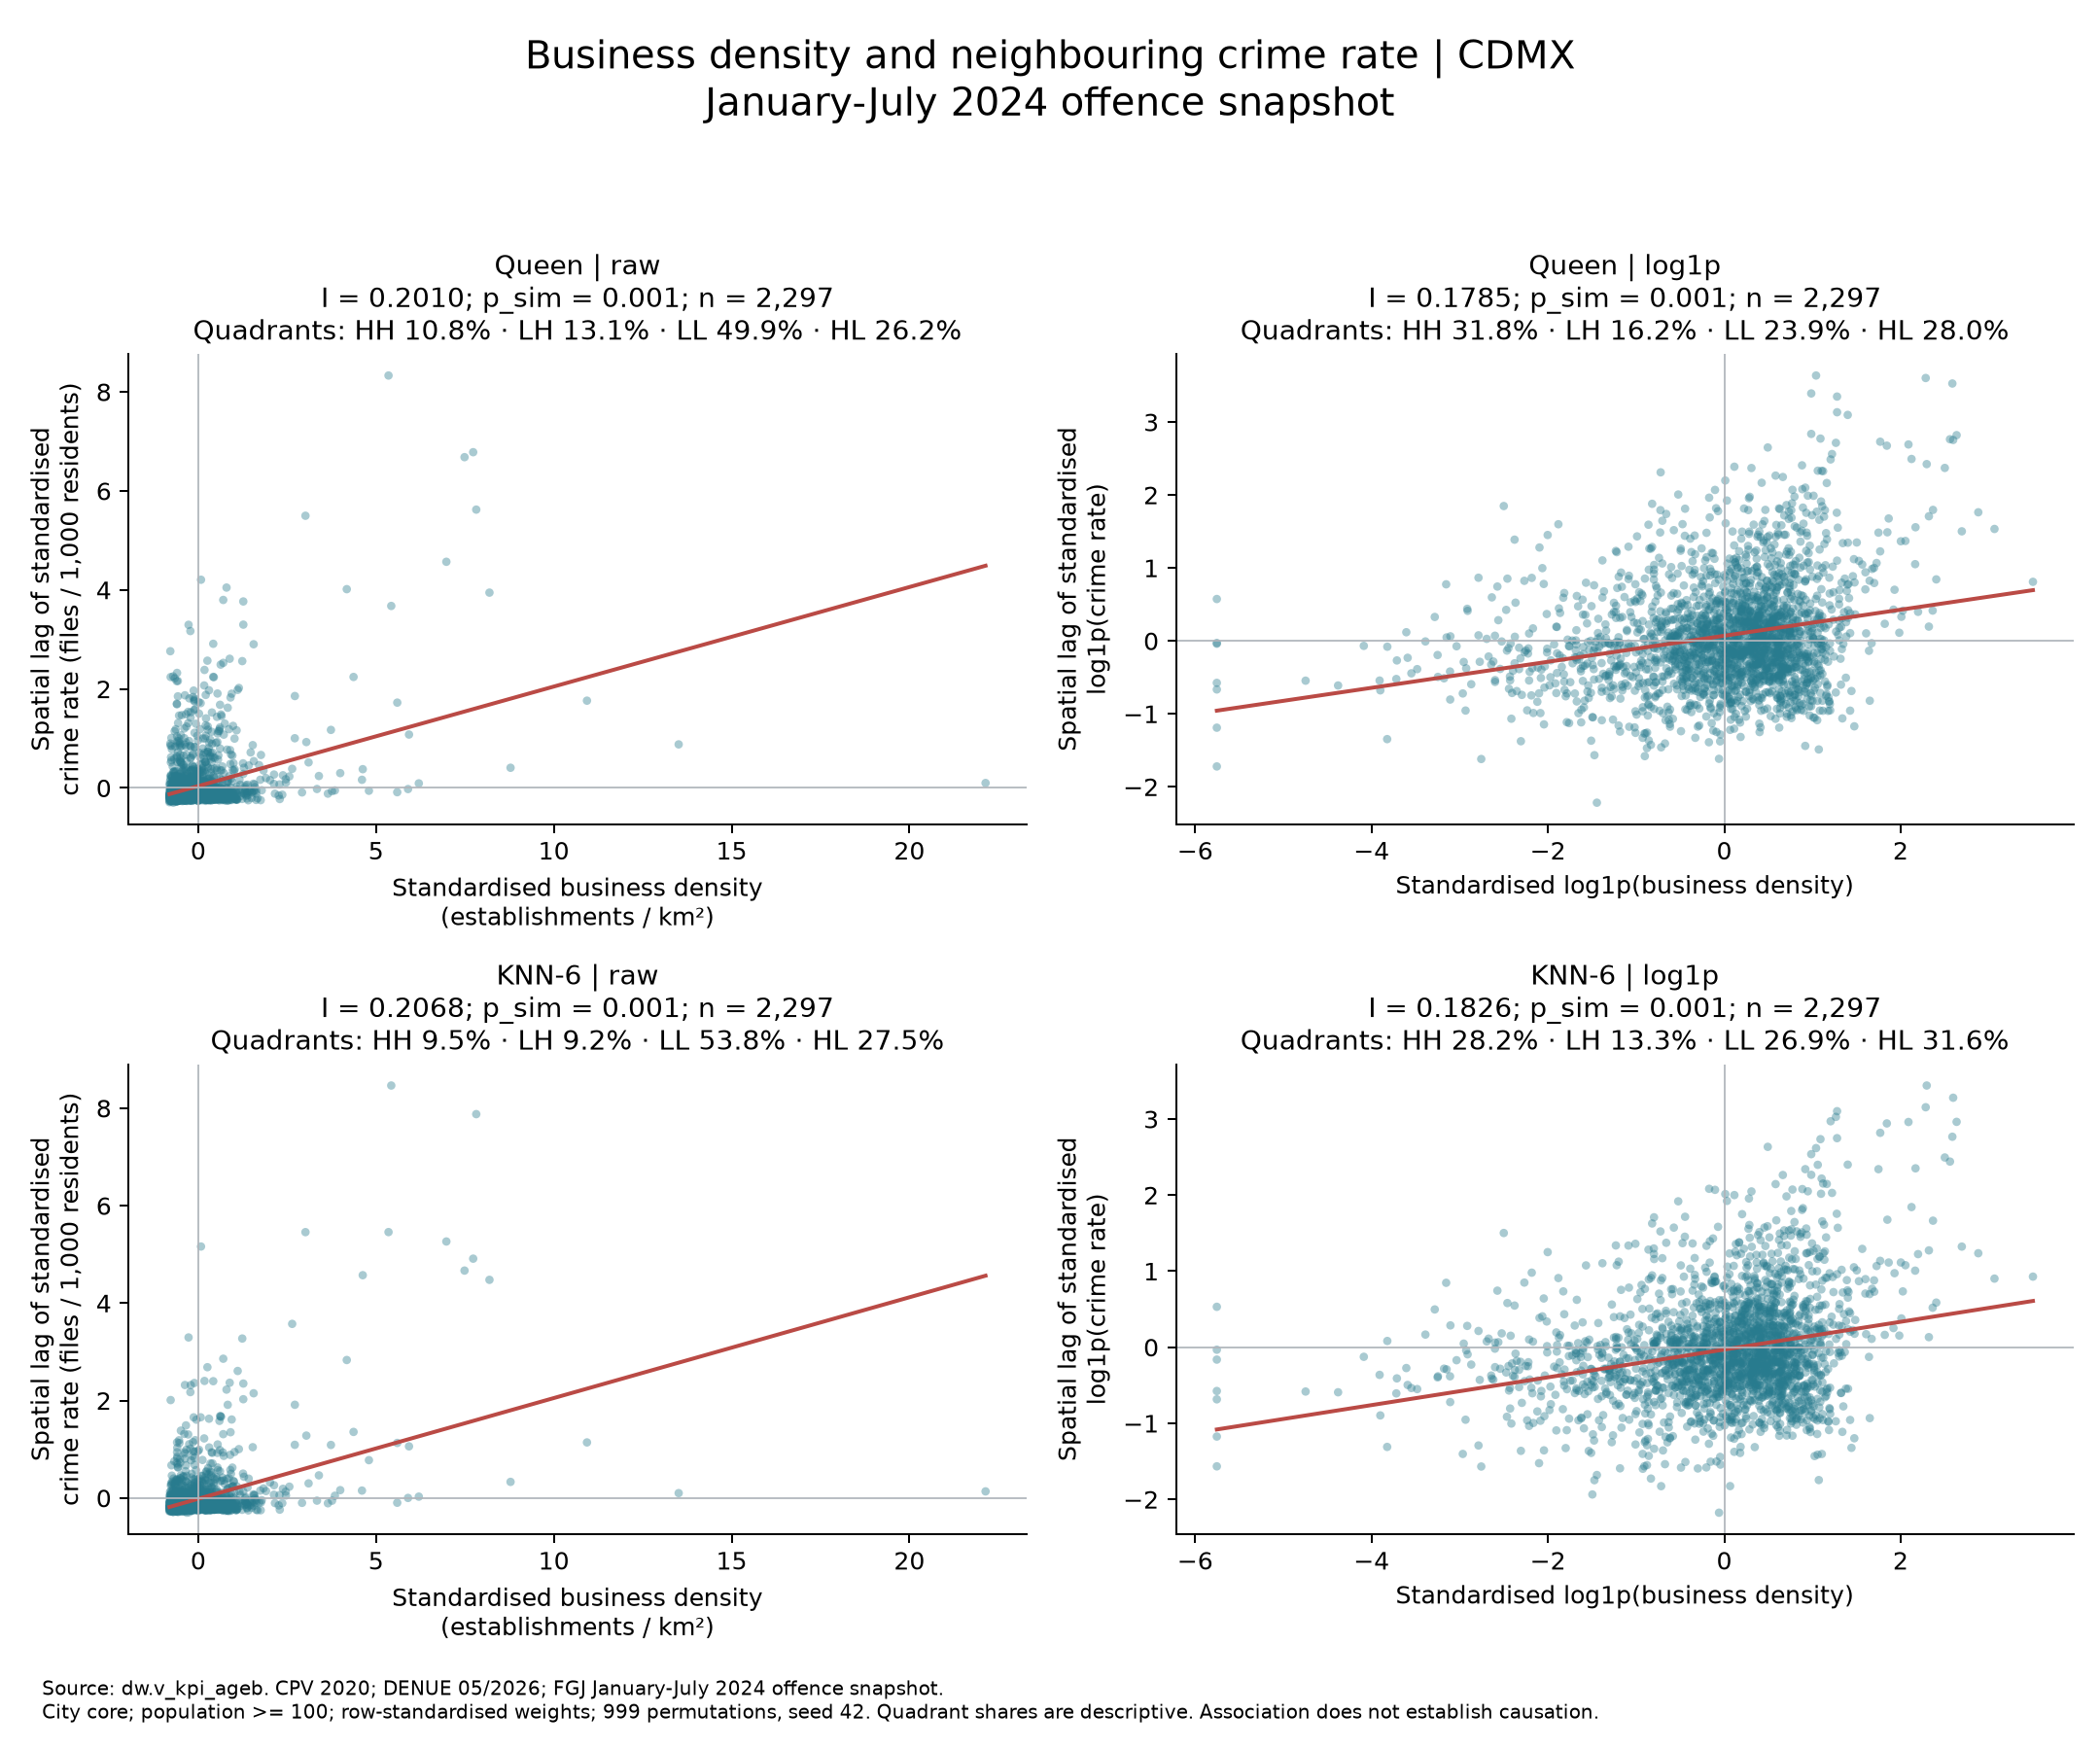

In [7]:
results, statistics = bivariate_results(sample, permutations=PERMUTATIONS, seed=SEED)
assert results["n"].eq(len(sample)).all()
assert results["permutations"].eq(PERMUTATIONS).all()
assert results["islands_after_attachment"].eq(0).all()
assert results["p_sim"].between(1 / (PERMUTATIONS + 1), 1).all()
display(results.round({"I": 6, "p_sim": 3, "mean_neighbours": 3}))
results_path = OUTPUT_FIGURES / "33_bivariate_business_crime.csv"
results.to_csv(results_path, index=False)
quadrants = bivariate_quadrants(statistics)
quadrants_path = OUTPUT_FIGURES / "33_bivariate_quadrants.csv"
quadrants.to_csv(quadrants_path, index=False)
display(quadrants.round(1))
bivariate_path = save_bivariate_figure(statistics, OUTPUT_FIGURES, seed=SEED,
                                        period_label="January-July 2024 offence snapshot")
display(Image(filename=str(bivariate_path)))

In [8]:
for row in results.itertuples(index=False):
    direction = "positive" if row.I > 0 else "negative"
    evidence = "below" if row.p_sim < ALPHA else "not below"
    print(f"{row.weights} / {row.scale}: I = {row.I:.6f}, p_sim = {row.p_sim:.3f}, "
          f"n = {row.n:,}; {direction} association, pseudo p-value {evidence} alpha = {ALPHA}.")
for row in quadrants.itertuples(index=False):
    print(f"{row.weights} / {row.scale}: HH {row.pct_HH:.1f}%, LL {row.pct_LL:.1f}%, "
          f"HL {row.pct_HL:.1f}%, LH {row.pct_LH:.1f}% of AGEBs (HH + LL = {row.pct_HH + row.pct_LL:.1f}%).")
print("The observed association does not establish that businesses cause crime or vice versa. "
      "Urban intensity, resident denominators, reporting and other shared spatial patterns may contribute.")

Queen / raw: I = 0.201020, p_sim = 0.001, n = 2,297; positive association, pseudo p-value below alpha = 0.05.
Queen / log1p: I = 0.178525, p_sim = 0.001, n = 2,297; positive association, pseudo p-value below alpha = 0.05.
KNN-6 / raw: I = 0.206815, p_sim = 0.001, n = 2,297; positive association, pseudo p-value below alpha = 0.05.
KNN-6 / log1p: I = 0.182574, p_sim = 0.001, n = 2,297; positive association, pseudo p-value below alpha = 0.05.
Queen / raw: HH 10.8%, LL 49.9%, HL 26.2%, LH 13.1% of AGEBs (HH + LL = 60.7%).
Queen / log1p: HH 31.8%, LL 23.9%, HL 28.0%, LH 16.2% of AGEBs (HH + LL = 55.7%).
KNN-6 / raw: HH 9.5%, LL 53.8%, HL 27.5%, LH 9.2% of AGEBs (HH + LL = 63.3%).
KNN-6 / log1p: HH 28.2%, LL 26.9%, HL 31.6%, LH 13.3% of AGEBs (HH + LL = 55.1%).
The observed association does not establish that businesses cause crime or vice versa. Urban intensity, resident denominators, reporting and other shared spatial patterns may contribute.


### Scatterplot quadrants (cluster interpretation)

Each AGEB falls in one quadrant of the scatterplot: its standardised business density (above or below the sample mean) against the spatial lag of the standardised crime rate in its neighbours. HH and LL are the concordant quadrants that drive a positive I.

- On the raw scale, about half of the AGEBs are **LL** (49.9% Queen, 53.8% KNN-6): below-average business density next to below-average neighbouring crime rates. **HH** covers only 10.8% (Queen) and 9.5% (KNN-6), because a few extreme AGEBs pull the means up (business density up to 22,207 establishments/km²; crime rate up to 1,436 files per 1,000 residents).
- On the log1p scale the quadrants are more balanced: HH 31.8% (Queen) / 28.2% (KNN-6) and LL 23.9% / 26.9%.
- **HL** is large under every specification (26.2-31.6%): many AGEBs with above-average business density border AGEBs with below-average crime rates, so business density alone does not locate high neighbouring crime.
- The concordant quadrants (HH + LL) hold 55.1-63.3% of the AGEBs.

Quadrants are descriptive positions on the scatterplot, not significance tests. They do not identify local clusters or hotspots, which would need a local bivariate statistic with multiple-testing control.

## 3. Interpretation and report handoff

- Census **2020**, offence records **January-July 2024**, and DENUE **05/2026** describe different time frames. The rate is not an individual victimisation probability, and resident populations omit commuters and visitors.
- Temporal summaries cover all 2,431 urban AGEBs; bivariate inference uses the filtered city-core sample stated above. Results should not be extrapolated to rural CDMX or Mérida.
- Reported files underrepresent unreported crimes. Excluded coordinates, strict polygon assignment, opening-date organisation and unknown hours constrain the observed sample.
- Suppressed census values remain NULL; zero denominators remain NULL. Rate-based spatial analysis excludes AGEBs with fewer than 100 residents.
- AGEB boundaries and aggregation scale can alter results (MAUP). These global statistics and the descriptive quadrant shares do not locate local hotspots and do not support individual-level or causal conclusions.

The problem and source inventory are in [report/sections/1_problem_data_sources.md](../report/sections/1_problem_data_sources.md); interpretation limits are in [report/sections/6_limitations.md](../report/sections/6_limitations.md). These exports provide the temporal and bivariate evidence for Gustavo's findings section; Local Moran/LISA and alcaldía comparisons retain their separate team ownership.

In [9]:
metadata = {
    "analysis": "Valeria / notebook 33 / crime patterns and bivariate Moran",
    "executed_at_utc": datetime.now(timezone.utc).isoformat(),
    "crime_year": CRIME_YEAR,
    "filing_window": [COVERAGE_START, COVERAGE_END],
    "crime_source_sha256": warehouse_sha256,
    "crime_source_sha256_checked_against": "dw.dim_source",
    "right_censored_month": int(monthly.index[monthly["right_censored"]][0]),
    "weekday_sensitivity_window": [COVERAGE_START, SENSITIVITY_END],
    "annualised": False,
    "warehouse_views": ["dw.v_kpi_ageb", "dw.v_crime_by_type_time"],
    "source_versions": {key: source["version_label"] for key, source in SOURCES.items()},
    "temporal_agebs": len(all_kpis), "temporal_incidents": warehouse_total,
    "bivariate_n": len(sample), "city_core_only": True, "exclude_low_population": True,
    "additional_incomplete_pairs": int((~finite).sum()),
    "x": pair[0], "spatial_lag_of": pair[1],
    "scales": ["raw", "log1p"], "weights": ["Queen", "KNN-6"],
    "permutations": PERMUTATIONS, "seed": SEED, "alpha": ALPHA,
    "p_value": "esda.Moran_BV.p_sim (smaller permutation tail)",
    "quadrants": "sign of standardised x vs spatial lag of standardised y; descriptive, not tested",
    "software": software,
}
metadata_path = OUTPUT_FIGURES / "33_crime_analysis_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
for path in [*table_paths.values(), *figure_paths.values(), sensitivity_path, results_path, quadrants_path, bivariate_path, metadata_path]:
    print(path.relative_to(ROOT))

outputs\figures\crime_monthly.csv
outputs\figures\crime_weekday.csv
outputs\figures\crime_time_band.csv
outputs\figures\crime_crime_type.csv
outputs\figures\crime_weekday_time_band_per_day.csv
outputs\figures\crime_month_by_category.csv
outputs\figures\crime_day_of_week_by_category.csv
outputs\figures\crime_time_band_by_category.csv
outputs\figures\crime_monthly_2024.png
outputs\figures\crime_weekday_2024.png
outputs\figures\crime_time_band_2024.png
outputs\figures\crime_top_types_2024.png
outputs\figures\crime_weekday_time_band_2024.png
outputs\figures\crime_temporal_patterns.png
outputs\figures\crime_weekday_sensitivity.csv
outputs\figures\33_bivariate_business_crime.csv
outputs\figures\33_bivariate_quadrants.csv
outputs\figures\bivariate_moran_business_crime.png
outputs\figures\33_crime_analysis_metadata.json
